In [4]:
!pip install requests pandas vaderSentiment matplotlib

In [6]:
import requests
import pandas as pd
from datetime import datetime, timedelta
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

In [83]:
#MyAPI Key
import streamlit as st
API_KEY = "your_newsapi_key_here"

In [12]:
#ticket defined
ticker = "AAPL"

In [16]:
#define from_date
today = datetime.utcnow().date()
from_date = today - timedelta(days=7)

print("From date:", from_date)
print("To date:", today)

From date: 2026-03-01
To date: 2026-03-08


/var/folders/0t/njb1qx7s6n51t4tjhdtbp4qr0000gn/T/ipykernel_9886/2872972868.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  today = datetime.utcnow().date()


In [18]:
#Fetch news from NewsAPI
url = "https://newsapi.org/v2/everything"

params = {
    "q": ticker,
    "from": from_date.isoformat(),
    "to": today.isoformat(),
    "language": "en",
    "sortBy": "publishedAt",
    "pageSize": 20,
    "apiKey": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

print("Status code:", response.status_code)
print("Total results:", data.get("totalResults"))
print("Keys in response:", data.keys())

Status code: 200
Total results: 35
Keys in response: dict_keys(['status', 'totalResults', 'articles'])


In [22]:
#check few articles
articles = data.get("articles", [])

print("Number of articles returned:", len(articles))

for article in articles[:5]:
    print("-" * 50)
    print("Title:", article.get("title"))
    print("Source:", article.get("source", {}).get("name"))
    print("Published:", article.get("publishedAt"))

Number of articles returned: 20
--------------------------------------------------
Title: Apple Stock Slips 1.09% as Geopolitical Jitters Offset Fresh Product Momentum
Source: Ibtimes.com.au
Published: 2026-03-07T13:46:40Z
--------------------------------------------------
Title: Billionaire Peter Thiel Dumps $74,400,000 Stake in Three Assets, Including One Warren Buffett Favorite
Source: The Daily Hodl
Published: 2026-03-07T08:04:26Z
--------------------------------------------------
Title: The $200 Billion Question: Is Amazon Finally Ready to Pay a Dividend?
Source: Barchart.com
Published: 2026-03-07T00:00:02Z
--------------------------------------------------
Title: A $100 Billion and More Reasons to Buy Broadcom Stock Now
Source: Barchart.com
Published: 2026-03-06T20:40:17Z
--------------------------------------------------
Title: Apple Just Unveiled the New iPhone 17e. Should You Buy, Sell, or Hold AAPL Stock Now?
Source: Yahoo Entertainment
Published: 2026-03-06T20:17:40Z


In [24]:
#Convert articles into a DataFrame
rows = []

for article in articles:
    rows.append({
        "title": article.get("title"),
        "source": article.get("source", {}).get("name"),
        "publishedAt": article.get("publishedAt"),
        "description": article.get("description"),
        "url": article.get("url")
    })

df = pd.DataFrame(rows)
df.head()

,title,source,publishedAt,description,url
0,Apple Stock Slips 1.09% as Geopolitical Jitter...,Ibtimes.com.au,2026-03-07T13:46:40Z,Apple Inc. shares declined modestly on March 6...,https://www.ibtimes.com.au/apple-stock-slips-1...
1,"Billionaire Peter Thiel Dumps $74,400,000 Stak...",The Daily Hodl,2026-03-07T08:04:26Z,Billionaire investor and entrepreneur Peter Th...,https://dailyhodl.com/2026/03/07/billionaire-p...
2,The $200 Billion Question: Is Amazon Finally R...,Barchart.com,2026-03-07T00:00:02Z,Will Amazon pay a dividend? I'll explain AMZN’...,https://www.barchart.com/story/news/617144/the...
3,A $100 Billion and More Reasons to Buy Broadco...,Barchart.com,2026-03-06T20:40:17Z,Six companies could create a $100 billion AI o...,https://www.barchart.com/story/news/614554/a-1...
4,Apple Just Unveiled the New iPhone 17e. Should...,Yahoo Entertainment,2026-03-06T20:17:40Z,None,https://consent.yahoo.com/v2/collectConsent?se...


In [28]:
#Check shape and columns
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (20, 5)
Columns: ['title', 'source', 'publishedAt', 'description', 'url']


In [30]:
#Create the VADER Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

In [32]:
#Create a function to label sentiment
def get_sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [34]:
#Combine title and description for analysis
df["title"] = df["title"].fillna("")
df["description"] = df["description"].fillna("")

df["text_for_scoring"] = df["title"] + ". " + df["description"]

df[["title", "text_for_scoring"]].head()

,title,text_for_scoring
0,Apple Stock Slips 1.09% as Geopolitical Jitter...,Apple Stock Slips 1.09% as Geopolitical Jitter...
1,"Billionaire Peter Thiel Dumps $74,400,000 Stak...","Billionaire Peter Thiel Dumps $74,400,000 Stak..."
2,The $200 Billion Question: Is Amazon Finally R...,The $200 Billion Question: Is Amazon Finally R...
3,A $100 Billion and More Reasons to Buy Broadco...,A $100 Billion and More Reasons to Buy Broadco...
4,Apple Just Unveiled the New iPhone 17e. Should...,Apple Just Unveiled the New iPhone 17e. Should...


In [36]:
#Run VADER sentiment analysis
df["compound_score"] = df["text_for_scoring"].apply(
    lambda text: analyzer.polarity_scores(text)["compound"]
)

df["sentiment"] = df["compound_score"].apply(get_sentiment_label)

df[["title", "compound_score", "sentiment"]].head(10)

,title,compound_score,sentiment
0,Apple Stock Slips 1.09% as Geopolitical Jitter...,0.3612,Positive
1,"Billionaire Peter Thiel Dumps $74,400,000 Stak...",0.3400,Positive
2,The $200 Billion Question: Is Amazon Finally R...,0.2168,Positive
3,A $100 Billion and More Reasons to Buy Broadco...,0.3506,Positive
4,Apple Just Unveiled the New iPhone 17e. Should...,0.0000,Neutral
5,OKX is building a social network directly into...,0.4404,Positive
6,Apple just made it easier for people to become...,0.6808,Positive
7,3 world-class ASX ETFs to buy and hold,0.2960,Positive
8,polygon-options-puller added to PyPI,0.0000,Neutral
9,caracal-trading added to PyPI,0.0000,Neutral


In [38]:
#count sentiment categories
df["sentiment"].value_counts()

sentiment
Positive    11
Neutral      8
Negative     1
Name: count, dtype: int64

In [42]:
#calculate overall sentiment score
overall_score = df["compound_score"].mean()

print("Overall score:", round(overall_score, 3))

Overall score: 0.238


In [44]:
#Convert overall score to Bullish / Neutral / Bearish
def get_overall_label(score):
    if score >= 0.05:
        return "Bullish"
    elif score <= -0.05:
        return "Bearish"
    else:
        return "Neutral"

overall_label = get_overall_label(overall_score)

print("Overall Market Sentiment:", overall_label)

Overall Market Sentiment: Bullish


In [46]:
#Visualization: Convert date column
df["publishedAt"] = pd.to_datetime(df["publishedAt"], errors="coerce")
df["date"] = df["publishedAt"].dt.date

df[["publishedAt", "date"]].head()

,publishedAt,date
0,2026-03-07 13:46:40+00:00,2026-03-07
1,2026-03-07 08:04:26+00:00,2026-03-07
2,2026-03-07 00:00:02+00:00,2026-03-07
3,2026-03-06 20:40:17+00:00,2026-03-06
4,2026-03-06 20:17:40+00:00,2026-03-06


In [48]:
#Calculate daily sentiment trend
daily_df = df.groupby("date")["compound_score"].mean().reset_index()

daily_df

,date,compound_score
0,2026-03-03,0.318375
1,2026-03-04,-0.020375
2,2026-03-05,0.308617
3,2026-03-06,0.263667
4,2026-03-07,0.306000


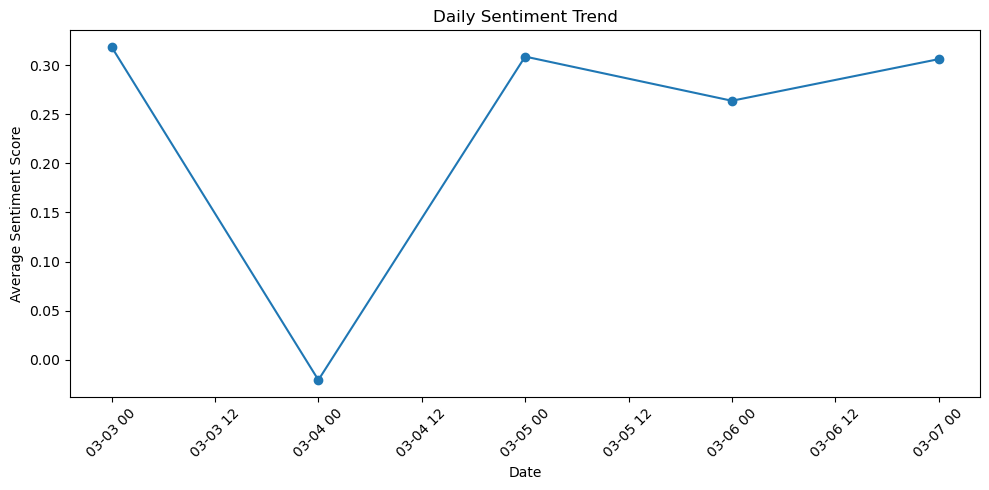

In [50]:
#Plot sentiment trend graph
plt.figure(figsize=(10,5))

plt.plot(daily_df["date"], daily_df["compound_score"], marker="o")

plt.title("Daily Sentiment Trend")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [52]:
#Create a clean final results table
final_df = df[[
    "title",
    "source",
    "publishedAt",
    "compound_score",
    "sentiment",
    "url"
]]

final_df.head(10)

,title,source,publishedAt,compound_score,sentiment,url
0,Apple Stock Slips 1.09% as Geopolitical Jitter...,Ibtimes.com.au,2026-03-07 13:46:40+00:00,0.3612,Positive,https://www.ibtimes.com.au/apple-stock-slips-1...
1,"Billionaire Peter Thiel Dumps $74,400,000 Stak...",The Daily Hodl,2026-03-07 08:04:26+00:00,0.3400,Positive,https://dailyhodl.com/2026/03/07/billionaire-p...
2,The $200 Billion Question: Is Amazon Finally R...,Barchart.com,2026-03-07 00:00:02+00:00,0.2168,Positive,https://www.barchart.com/story/news/617144/the...
3,A $100 Billion and More Reasons to Buy Broadco...,Barchart.com,2026-03-06 20:40:17+00:00,0.3506,Positive,https://www.barchart.com/story/news/614554/a-1...
4,Apple Just Unveiled the New iPhone 17e. Should...,Yahoo Entertainment,2026-03-06 20:17:40+00:00,0.0000,Neutral,https://consent.yahoo.com/v2/collectConsent?se...
5,OKX is building a social network directly into...,CoinDesk,2026-03-06 03:00:00+00:00,0.4404,Positive,https://www.coindesk.com/business/2026/03/05/o...
6,Apple just made it easier for people to become...,Macdailynews.com,2026-03-05 21:40:30+00:00,0.6808,Positive,https://macdailynews.com/2026/03/05/apple-just...
7,3 world-class ASX ETFs to buy and hold,Motley Fool Australia,2026-03-05 21:15:16+00:00,0.2960,Positive,https://www.fool.com.au/2026/03/06/3-world-cla...
8,polygon-options-puller added to PyPI,Pypi.org,2026-03-05 10:54:33+00:00,0.0000,Neutral,https://pypi.org/project/polygon-options-puller/
9,caracal-trading added to PyPI,Pypi.org,2026-03-05 08:13:48+00:00,0.0000,Neutral,https://pypi.org/project/caracal-trading/


In [54]:
#Export results to CSV
file_name = f"{ticker}_sentiment_results.csv"

final_df.to_csv(file_name, index=False)

print("File saved:", file_name)

File saved: AAPL_sentiment_results.csv


In [56]:
positive = (df["sentiment"] == "Positive").sum()
neutral = (df["sentiment"] == "Neutral").sum()
negative = (df["sentiment"] == "Negative").sum()

print("Ticker:", ticker)
print("Total Articles:", len(df))
print("Positive Articles:", positive)
print("Neutral Articles:", neutral)
print("Negative Articles:", negative)
print("Overall Score:", round(overall_score,3))
print("Market Sentiment:", overall_label)

Ticker: AAPL
Total Articles: 20
Positive Articles: 11
Neutral Articles: 8
Negative Articles: 1
Overall Score: 0.238
Market Sentiment: Bullish


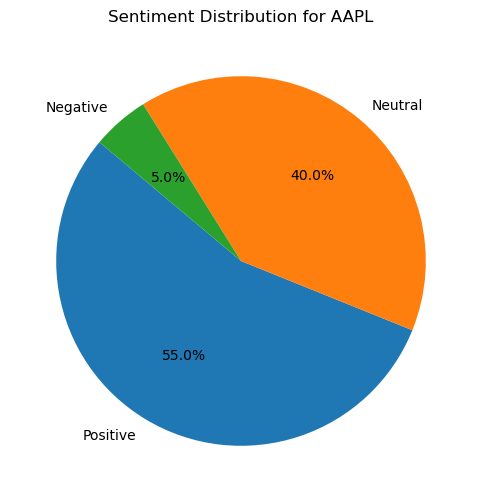

In [58]:
#Sentiment Distribution Pie Chart
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title(f"Sentiment Distribution for {ticker}")

plt.show()

In [60]:
#Most Common Words in News (Word Frequency)
from collections import Counter
import re

text = " ".join(df["text_for_scoring"])

# remove punctuation
text = re.sub(r'[^\w\s]', '', text)

words = text.lower().split()

# remove very common words
stopwords = {"the","a","and","to","of","in","for","on","with","is","are","that","this"}

filtered_words = [w for w in words if w not in stopwords and len(w) > 3]

word_counts = Counter(filtered_words)

word_counts.most_common(10)

[('display', 12),
 ('apple', 8),
 ('post', 8),
 ('appeared', 8),
 ('first', 8),
 ('2026とstudio', 6),
 ('billion', 5),
 ('easy', 5),
 ('stock', 4),
 ('from', 4)]

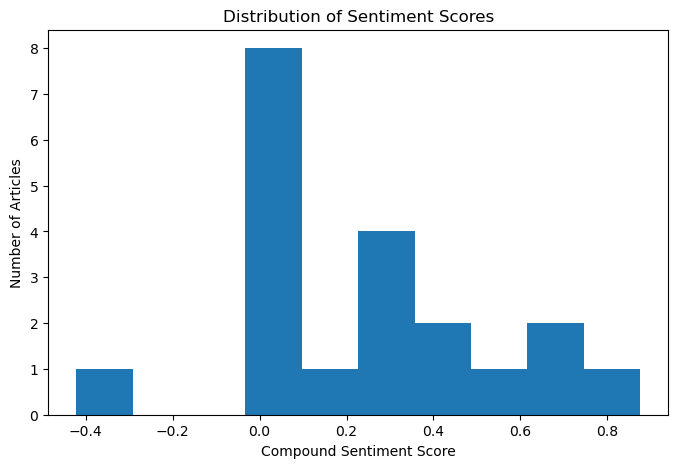

In [62]:
#Sentiment Score Histogram
plt.figure(figsize=(8,5))

plt.hist(df["compound_score"], bins=10)

plt.title("Distribution of Sentiment Scores")
plt.xlabel("Compound Sentiment Score")
plt.ylabel("Number of Articles")

plt.show()

In [64]:
print("========== Sentiment Summary ==========")
print("Ticker:", ticker)
print("Total Articles:", len(df))
print("Positive:", (df["sentiment"]=="Positive").sum())
print("Neutral:", (df["sentiment"]=="Neutral").sum())
print("Negative:", (df["sentiment"]=="Negative").sum())
print("Overall Score:", round(overall_score,3))
print("Market Sentiment:", overall_label)

========== Sentiment Summary ==========
Ticker: AAPL
Total Articles: 20
Positive: 11
Neutral: 8
Negative: 1
Overall Score: 0.238
Market Sentiment: Bullish


In [66]:
#Install Streamlit
!pip install streamlit plotly python-dotenv

In [76]:
import streamlit
print(streamlit.__version__)

1.52.2


In [74]:
!streamlit run app.py


      👋 Welcome to Streamlit!

      If you'd like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  ^C
2026-03-08 14:09:32.694 
